# Data Understanding

Data Understanding adalah tahap untuk memahami dan mengeksplorasi kondisi awal dataset sebelum data diproses lebih lanjut.
Pada tahap ini dilakukan Exploratory Data Analysis (EDA) untuk mengetahui karakteristik data, seperti jumlah data, distribusi label, nilai kosong, data duplikat, dan panjang teks artikel.

In [23]:
import pandas as pd

df = pd.read_excel("../data/dataset_berita_200.xlsx")
print(" Dataset:", df.shape)
df.head()

 Dataset: (200, 4)


,id,isi_berita,label,url
0,1,Chef de Mission (CdM) Indonesia Todotua Pasari...,sport,https://sport.detik.com/sport-lain/d-8655308/c...
1,2,"Banjir besar melanda Nagoya, Jepang, menjelang...",sport,https://sport.detik.com/sport-lain/d-8655303/a...
2,3,Ketua Umum Komite Olimpiade Indonesia (KOI) Ra...,sport,https://sport.detik.com/sport-lain/d-8655067/k...
3,4,Persaingan titel juara dunia semakin ketat men...,sport,https://sport.detik.com/moto-gp/d-8654776/moto...
4,5,Sektor ganda campuran kembali mengalami peromb...,sport,https://sport.detik.com/raket/d-8654666/ganda-...


In [18]:
print("Info dataset:")
df.info()


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            200 non-null    int64 
 1   isi_berita    200 non-null    object
 2   label         200 non-null    object
 3   url           200 non-null    object
 4   panjang_teks  200 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 7.9+ KB


In [21]:
print("\nLabel:")
print(df["label"].value_counts())


Label:
label
sport      100
finance    100
Name: count, dtype: int64


In [15]:
print("\nCek nilai kosong:")
print(df.isnull().sum())


Cek nilai kosong:
id              0
isi_berita      0
label           0
url             0
panjang_teks    0
dtype: int64


In [14]:
print("\nCek duplikat isi_berita:")
print(df["isi_berita"].duplicated().sum())


Cek duplikat isi_berita:
0


In [3]:
df["panjang_teks"] = df["isi_berita"].apply(len)

print("Statistik panjang teks (karakter):")
print(df.groupby("label")["panjang_teks"].describe())

Statistik panjang teks (karakter):
         count     mean          std    min     25%     50%      75%     max
label                                                                       
finance  100.0  2596.74  1327.979308  826.0  1874.5  2291.0  2863.75  8169.0
sport    100.0  2274.33   812.942343  996.0  1704.0  2131.5  2630.50  5554.0


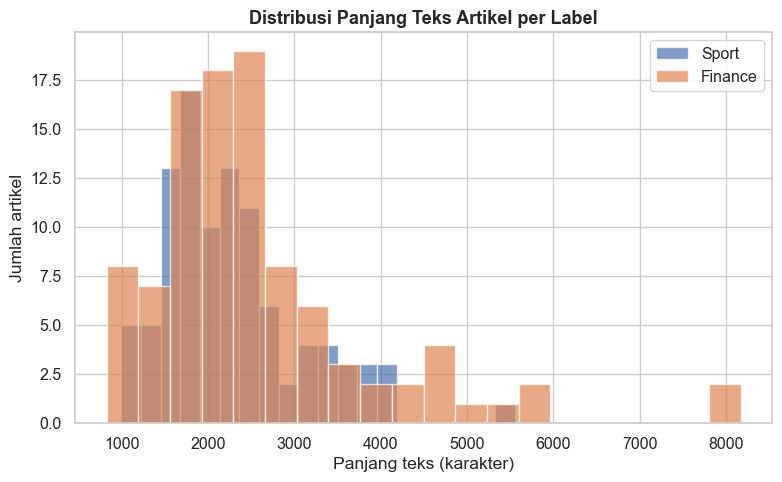

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram untuk label sport
ax.hist(
    df[df["label"] == "sport"]["panjang_teks"],
    bins=20,
    alpha=0.7,
    label="Sport"
)

# Histogram untuk label finance
ax.hist(
    df[df["label"] == "finance"]["panjang_teks"],
    bins=20,
    alpha=0.7,
    label="Finance"
)

ax.set_title(
    "Distribusi Panjang Teks Artikel per Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Panjang teks (karakter)")
ax.set_ylabel("Jumlah artikel")
ax.legend()

plt.tight_layout()
plt.show()

In [4]:
import sys

!{sys.executable} -m pip install matplotlib


[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Distribusi Kategori

In [6]:
import sys

!{sys.executable} -m pip install seaborn


[notice] A new release of pip available: 22.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


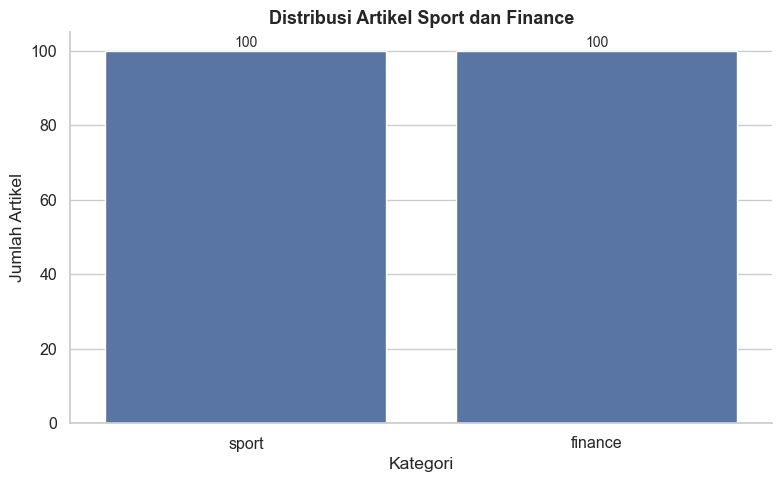

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.05)

# Menghitung jumlah artikel berdasarkan label
data = df["label"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=data.index,
    y=data.values
)

plt.title(
    "Distribusi Artikel Sport dan Finance",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Kategori")
plt.ylabel("Jumlah Artikel")

# Menampilkan jumlah di atas batang
for i, v in enumerate(data.values):
    plt.text(
        i,
        v + 1,
        str(v),
        ha="center",
        fontsize=10
    )

sns.despine()

plt.tight_layout()
plt.show()

## Contoh Artikel

In [11]:
contoh_sport = df[df["label"]=="sport"].sample(1, random_state=1).iloc[0]
contoh_finance = df[df["label"]=="finance"].sample(1, random_state=1).iloc[0]

print("=== CONTOH ARTIKEL SPORT ===")
print(contoh_sport["isi_berita"][:400], "...\n")

print("=== CONTOH ARTIKEL FINANCE ===")
print(contoh_finance["isi_berita"][:400], "...")

=== CONTOH ARTIKEL SPORT ===
Bilal Hasan memulai debut di UFC dengan meyakinkan, menang KO. Legenda UFC, Henry Cejudo dibikin kagum olehnya.
UFC Fight Night: Nurmagomedov vs Song dalam UFC Shanghai digelar di Oriental Sports Center, Sabtu (29/8). Bilal Hasan yang jalani laga debut, hadapi petarung asal Peru, Nilson Rojas di kelas flyweight.
Kedua petarung punya rekor sama 9-0. Bilal menang di ronde kedua setelah pukulan lurus ...

=== CONTOH ARTIKEL FINANCE ===
Seluruh bandara yang sebelumnya terdampak erupsi Gunung Anak Krakatau kembali dibuka untuk operasional penerbangan. Berdasarkan pembaruan Kantor Otoritas Bandar Udara Wilayah I Kelas Utama, terdapat delapan bandara yang telah kembali beroperasi.
Informasi tersebut disampaikan melalui pembaruan operasional penerbangan per Selasa (8/9/2026) pukul 10.00 WIB. Pembukaan dilakukan setelah sebelumnya ope ...


## Ringkasan Data Understanding

* Dataset terdiri dari **200 artikel berita**, dengan pembagian yang seimbang antara kategori `sport` sebanyak 100 artikel dan `finance` sebanyak 100 artikel.
* Tidak ditemukan **nilai kosong (missing value)** pada dataset.
* Tidak ditemukan **duplikat pada kolom `isi_berita`**, sehingga setiap artikel dapat dianggap sebagai data yang berbeda.
* Artikel kategori `sport` mencakup berbagai berita olahraga, sedangkan kategori `finance` mencakup berita ekonomi dan bisnis.
* Distribusi panjang teks artikel divisualisasikan menggunakan **histogram** untuk melihat penyebaran jumlah karakter pada masing-masing kategori.
* Histogram digunakan untuk membandingkan distribusi panjang teks antara artikel `sport` dan `finance`.
* Berdasarkan hasil eksplorasi awal, dataset dinyatakan **cukup baik dan siap digunakan pada tahap Data Preparation**.
